In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

src_path = Path.cwd() / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import dm_spikes as dm

In [2]:
M = 2.6e6
D = 8.5e3
rho0_iso = 0.0062
sigma_v = 100.0
m = 8.963e-56  # Msun
observable_sigma_v = 3.221e-74  # pc^3 / yr
bh_age = 1e10  # yr
R_S = dm.schwarzschild_radius(M)

In [3]:
for archivo in dm.list_density_profiles():
    print(archivo)

results\perfiles_densidad_gs_gammas_20260725_142613.npz
results\perfiles_densidad_gs_gammas_20260815_022159.npz
results\perfiles_densidad_gs_gammas_20260816_011532.npz
results\perfiles_densidad_gs_gammas_20260825_052140.npz


In [4]:
archivo_a_cargar = "results\perfiles_densidad_gs_gammas_20260825_052140.npz"
datos_cargados = False

try:
    perfiles = dm.load_density_profiles(archivo_a_cargar)
except FileNotFoundError:
    print("Edita archivo_a_cargar con el nombre del archivo .npz que quieras cargar.")
else:
    r_iso = perfiles["r_iso"]
    rho_iso = perfiles["rho_iso"]
    gamma_values = perfiles["gamma_values"]
    r_cusp_grid = perfiles["r_cusp"]
    rho_cusp_grid = perfiles["rho_cusp_grid"]
    datos_cargados = True

    print("Perfiles cargados desde archivo.")
    print("gamma_values:", gamma_values)
    print("r_cusp_grid.shape:", r_cusp_grid.shape)
    print("rho_cusp_grid.shape:", rho_cusp_grid.shape)

Perfiles cargados desde archivo.
gamma_values: [0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42
 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55 0.56
 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69 0.7
 0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83 0.84
 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98
 0.99 1.   1.01 1.02 1.03 1.04 1.05 1.06 1.07 1.08 1.09 1.1  1.11 1.12
 1.13 1.14 1.15 1.16 1.17 1.18 1.19 1.2  1.21 1.22 1.23 1.24 1.25 1.26
 1.27 1.28 1.29 1.3  1.31 1.32 1.33 1.34 1.35 1.36 1.37 1.38 1.39 1.4
 1.41 1.42 1.43 1.44 1.45 1.46 1.47 1.48 1.49 1.5  1.51 1.52 1.53 1.54
 1.55 1.56 1.57 1.58 1.59 1.6  1.61 1.62 1.63 1.64 1.65 1.66 1.67 1.68
 1.69 1.7  1.71 1.72 1.73 1.74 1.75 1.76 1.77 1.78 1.79 1.8  1.81 1.82
 1.83 1.84 1.85 1.86 1.87 1.88 1

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\luisa\AppData\Local\Temp\ipykernel_17152\379666490.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  archivo_a_cargar = "results\perfiles_densidad_gs_gammas_20260825_052140.npz"


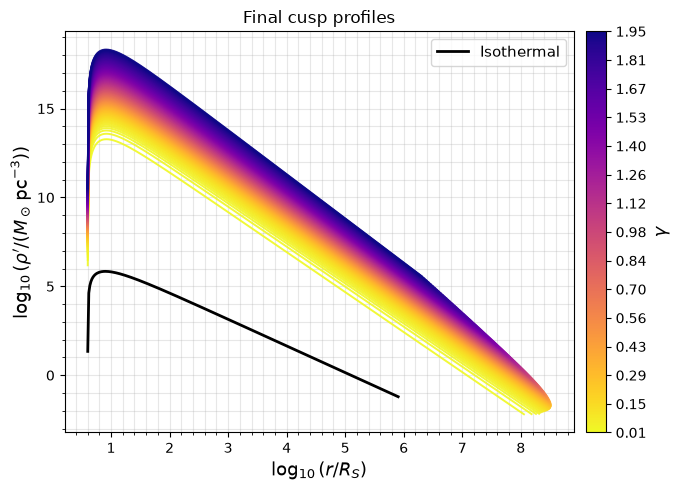

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

gamma_values = np.asarray(gamma_values, dtype=float)
norm = Normalize(vmin=gamma_values.min(), vmax=gamma_values.max())
cmap = plt.get_cmap("plasma_r")  #"viridis", "plasma", "turbo"

iso_line, = ax.plot(np.log10(r_iso / R_S),np.log10(rho_iso),color="black",lw=2,label="Isothermal")
for i, gamma_i in enumerate(gamma_values):
    r_cusp_i = r_cusp_grid[i]
    rho_i = rho_cusp_grid[i]

    valid_mask = (np.isfinite(r_cusp_i) & np.isfinite(rho_i) & (r_cusp_i > 0) & (rho_i > 0))

    ax.plot(
        np.log10(r_cusp_i[valid_mask] / R_S),
        np.log10(rho_i[valid_mask]),
        color=cmap(norm(gamma_i)),
        lw=1.4,
        alpha=0.9,
    )

colorbar_source = ScalarMappable(norm=norm, cmap=cmap)
colorbar_source.set_array([])
colorbar = fig.colorbar(colorbar_source, ax=ax, pad=0.02)
colorbar.set_label(r"$\gamma$", fontsize=13)
gamma_ticks = np.linspace(gamma_values.min(),gamma_values.max(),15)
colorbar.set_ticks(gamma_ticks)
colorbar.set_ticklabels([f"{gamma:.2f}" for gamma in gamma_ticks])

ax.legend(handles=[iso_line],loc="upper right",fontsize=11)
ax.set_xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
ax.set_ylabel(r"$\log_{10}(\rho'/(M_\odot\,\mathrm{pc}^{-3}))$",fontsize=13)
ax.set_title("Final cusp profiles")
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()

fig.tight_layout()
plt.show()

In [6]:
selected_gamma_values = np.array([0.01, 0.1, 1.0, 1.95])

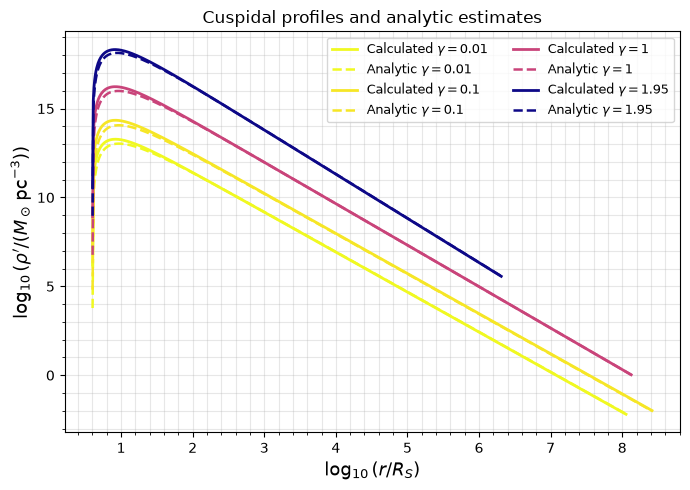

In [7]:
fig_comparison, ax_comparison = plt.subplots(figsize=(7, 5))

for gamma_comparison in selected_gamma_values:
    gamma_index = np.flatnonzero(np.isclose(gamma_values, gamma_comparison))[0]
    r_cusp_comparison = r_cusp_grid[gamma_index]
    rho_numeric_comparison = rho_cusp_grid[gamma_index]
    rho_analytic_comparison = dm.cusp_profile(
        r_cusp_comparison,
        M,
        float(gamma_comparison),
        R_S,
    )

    numeric_mask = (
        np.isfinite(r_cusp_comparison)
        & np.isfinite(rho_numeric_comparison)
        & (r_cusp_comparison > 0)
        & (rho_numeric_comparison > 0)
    )
    analytic_mask = (
        np.isfinite(r_cusp_comparison)
        & np.isfinite(rho_analytic_comparison)
        & (r_cusp_comparison > 0)
        & (rho_analytic_comparison > 0)
    )
    comparison_color = cmap(norm(gamma_comparison))

    ax_comparison.plot(
        np.log10(r_cusp_comparison[numeric_mask] / R_S),
        np.log10(rho_numeric_comparison[numeric_mask]),
        color=comparison_color,
        lw=2,
        label=fr"Calculated $\gamma={gamma_comparison:g}$",
    )
    ax_comparison.plot(
        np.log10(r_cusp_comparison[analytic_mask] / R_S),
        np.log10(rho_analytic_comparison[analytic_mask]),
        color=comparison_color,
        lw=1.8,
        ls="--",
        label=fr"Analytic $\gamma={gamma_comparison:g}$",
    )

ax_comparison.set_xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
ax_comparison.set_ylabel(
    r"$\log_{10}(\rho'/(M_\odot\,\mathrm{pc}^{-3}))$",
    fontsize=13,
)
ax_comparison.set_title("Cuspidal profiles and analytic estimates")
ax_comparison.grid(True, which="both", alpha=0.3)
ax_comparison.minorticks_on()
ax_comparison.legend(ncol=2, fontsize=9)

fig_comparison.tight_layout()
plt.show()

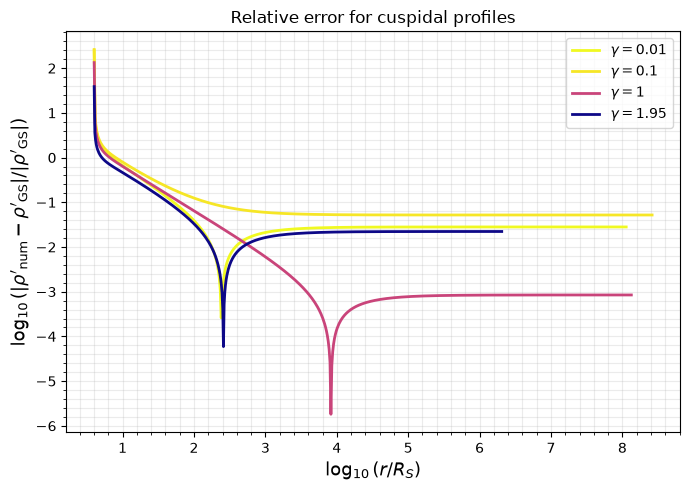

In [8]:
fig_relative_error, ax_relative_error = plt.subplots(figsize=(7, 5))

for gamma_error in selected_gamma_values:
    gamma_index = np.flatnonzero(np.isclose(gamma_values, gamma_error))[0]
    r_cusp_error = r_cusp_grid[gamma_index]
    rho_numeric_error = rho_cusp_grid[gamma_index]
    rho_analytic_error = dm.cusp_profile(
        r_cusp_error,
        M,
        float(gamma_error),
        R_S,
    )
    relative_error = dm.cusp_rel_error(
        rho_numeric_error,
        rho_analytic_error,
    )

    valid_error = (
        np.isfinite(r_cusp_error)
        & np.isfinite(relative_error)
        & (r_cusp_error > 0)
        & (relative_error > 0)
    )

    ax_relative_error.plot(
        np.log10(r_cusp_error[valid_error] / R_S),
        np.log10(relative_error[valid_error]),
        color=cmap(norm(gamma_error)),
        lw=2,
        label=fr"$\gamma={gamma_error:g}$",
    )

ax_relative_error.set_xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
ax_relative_error.set_ylabel(
    r"$\log_{10}(|\rho'_{\mathrm{num}}-\rho'_{\mathrm{GS}}|/|\rho'_{\mathrm{GS}}|)$",
    fontsize=13,
)
ax_relative_error.set_title("Relative error for cuspidal profiles")
ax_relative_error.grid(True, which="both", alpha=0.25)
ax_relative_error.minorticks_on()
ax_relative_error.legend(fontsize=10)

fig_relative_error.tight_layout()
plt.show()

In [9]:
import numpy as np
from scipy import special


def _as_float_array(value, name):
    array = np.asarray(value, dtype=float)
    if not np.all(np.isfinite(array)):
        raise ValueError(f"{name} must contain only finite values.")
    return array


def _return_scalar_if_scalar(value, scalar):
    if scalar:
        return float(np.asarray(value))
    return value


def _gamma_parameters(gamma):
    gamma = _as_float_array(gamma, "gamma")
    if np.any((gamma <= 0.0) | (gamma >= 2.0)):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")

    eps = 2.0 - gamma
    four_minus_gamma = 4.0 - gamma
    p = (6.0 - gamma) / four_minus_gamma
    beta = (6.0 - gamma) / (2.0 * eps)

    log_b = np.log(np.pi) + np.log(eps) - special.betaln(1.0 / eps, 1.5)
    log_lambda = -np.log1p(eps / 2.0) / eps + 0.5 * (np.log(eps) - np.log(four_minus_gamma))
    log_b_lambda = log_b + log_lambda
    kappa_factor = -np.expm1(-log_b_lambda)
    if np.any(kappa_factor <= 0.0):
        raise FloatingPointError("kappa_gamma is not positive for the supplied gamma values.")
    log_kappa = np.log(2.0) + np.log(kappa_factor)

    return beta, p, log_b, log_kappa


def _J_gamma(eta, gamma, *, rtol=1e-12, max_terms=1000, include_tail=True):
    if rtol <= 0.0:
        raise ValueError("rtol must be positive.")
    if max_terms < 1:
        raise ValueError("max_terms must be at least 1.")

    eta = _as_float_array(eta, "eta")
    gamma = _as_float_array(gamma, "gamma")
    _, p, log_b, log_kappa = _gamma_parameters(gamma)
    eta, p, log_b, log_kappa = np.broadcast_arrays(eta, p, log_b, log_kappa)

    if include_tail:
        below = eta < 0.0
        above = eta > 1.0
        if np.any(below & (np.abs(eta) > rtol)) or np.any(above & ((eta - 1.0) > rtol)):
            raise ValueError("eta must satisfy 0 <= eta <= 1, up to roundoff.")
        eta = np.where(below, 0.0, eta)
        eta = np.where(above, 1.0, eta)

    total = np.zeros_like(p, dtype=float)
    tiny = np.finfo(float).tiny

    for n in range(max_terms):
        n_float = float(n)
        a_tail = n_float / 2.0 + 1.0
        c_tail = (p + n_float + 3.0) / 2.0
        log_term = (
            -p * log_b
            - np.log(2.0)
            + special.gammaln(p + n_float)
            - special.gammaln(p)
            - special.gammaln(n_float + 1.0)
            + n_float * log_kappa
            + special.betaln((p + n_float) / 2.0 + 1.0, 0.5)
            + special.betaln(a_tail, c_tail)
        )
        term = np.exp(log_term)
        if include_tail:
            term = term * special.betaincc(a_tail, c_tail, eta)
        total = total + term

        scale = np.maximum(np.abs(total), tiny)
        if np.all(np.abs(term) <= rtol * scale):
            return total

    raise RuntimeError("The analytic beta-function series did not converge before max_terms.")


def alpha_gamma_exact(gamma, *, rtol=1e-12, max_terms=1000):
    """Return alpha_gamma for 0 < gamma < 2 using the analytic beta-function series.

    Parameters: gamma is a scalar or array; rtol and max_terms control series convergence.
    Returns: float for scalar gamma, otherwise numpy.ndarray.
    Domain: 0 < gamma < 2.
    """
    scalar = np.isscalar(gamma) or np.asarray(gamma).shape == ()
    gamma = _as_float_array(gamma, "gamma")
    beta, p, _, _ = _gamma_parameters(gamma)
    J0 = _J_gamma(np.zeros_like(gamma, dtype=float), gamma, rtol=rtol, max_terms=max_terms, include_tail=False)

    a_gamma = (3.0 - gamma) / (4.0 - gamma)
    s_gamma = (3.0 - gamma) ** 2 / (4.0 - gamma)
    log_alpha = (
        np.log(J0)
        + (p + 1.0) * np.log(2.0)
        - 0.5 * np.log(np.pi)
        + special.gammaln(beta)
        - special.gammaln(beta - 1.5)
        + a_gamma * np.log((3.0 - gamma) * (2.0 - gamma) / (4.0 * np.pi))
    ) / s_gamma

    return _return_scalar_if_scalar(np.exp(log_alpha), scalar)


def g_gamma_exact(r, gamma, R_S, *, rtol=1e-12, max_terms=1000):
    """Return g_gamma(r) = J_gamma(4 R_S / r) / J_gamma(0).

    Parameters: r and gamma broadcast as NumPy arrays; R_S is the scale radius; rtol and max_terms control convergence.
    Returns: float for scalar inputs, otherwise numpy.ndarray.
    Domain: 0 < gamma < 2, R_S > 0, and r >= 4 R_S.
    """
    scalar = (
        (np.isscalar(r) or np.asarray(r).shape == ())
        and (np.isscalar(gamma) or np.asarray(gamma).shape == ())
        and (np.isscalar(R_S) or np.asarray(R_S).shape == ())
    )
    r = _as_float_array(r, "r")
    gamma = _as_float_array(gamma, "gamma")
    R_S = _as_float_array(R_S, "R_S")
    if np.any(R_S <= 0.0):
        raise ValueError("R_S must be positive.")

    r, gamma, R_S = np.broadcast_arrays(r, gamma, R_S)
    lower = 4.0 * R_S
    too_small = r < lower
    if np.any(too_small & ((lower - r) > rtol * lower)):
        raise ValueError("r must satisfy r >= 4 R_S, up to roundoff.")
    r = np.where(too_small, lower, r)

    eta = lower / r
    J_eta = _J_gamma(eta, gamma, rtol=rtol, max_terms=max_terms, include_tail=True)
    J0 = _J_gamma(np.zeros_like(eta, dtype=float), gamma, rtol=rtol, max_terms=max_terms, include_tail=False)
    result = J_eta / J0

    below = result < 0.0
    above = result > 1.0
    if np.any(below & (np.abs(result) > rtol)) or np.any(above & ((result - 1.0) > rtol)):
        raise FloatingPointError("g_gamma(r) fell outside [0, 1] beyond roundoff.")
    result = np.where(below, 0.0, result)
    result = np.where(above, 1.0, result)

    return _return_scalar_if_scalar(result, scalar)


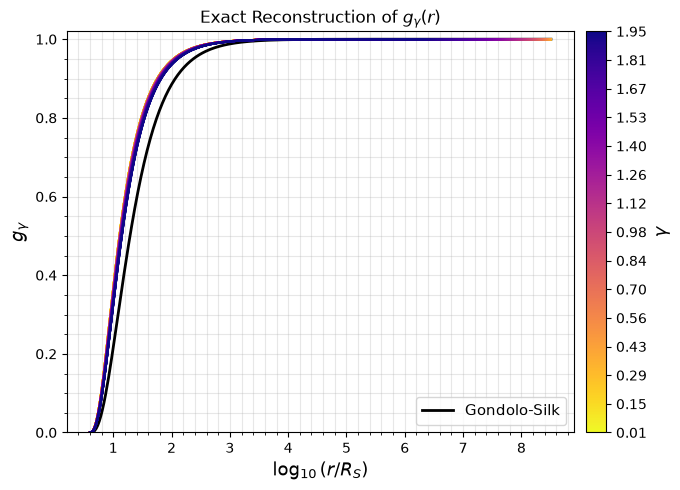

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

gamma_values = np.asarray(gamma_values, dtype=float)
r_cusp_grid = np.asarray(r_cusp_grid, dtype=float)
g_gamma_grid = g_gamma_exact(r_cusp_grid, gamma_values[:, None], R_S)

norm = Normalize(vmin=gamma_values.min(), vmax=gamma_values.max())
cmap = plt.get_cmap("plasma_r")

r_gs = np.geomspace(
    max(4.001 * R_S, np.min(r_cusp_grid)),
    np.max(r_cusp_grid),
    300,
)
gs_line, = ax.plot(
    np.log10(r_gs / R_S),
    (1.0 - 4.0 * R_S / r_gs) ** 3,
    color="black",
    lw=2,
    label="Gondolo-Silk",
)

for gamma_i, r_cusp_i, g_gamma_i in zip(gamma_values, r_cusp_grid, g_gamma_grid):
    valid_mask = (
        np.isfinite(r_cusp_i)
        & np.isfinite(g_gamma_i)
        & (r_cusp_i >= 4.0 * R_S)
    )
    ax.plot(
        np.log10(r_cusp_i[valid_mask] / R_S),
        g_gamma_i[valid_mask],
        color=cmap(norm(gamma_i)),
        lw=1.4,
        alpha=0.9,
    )

colorbar_source = ScalarMappable(norm=norm, cmap=cmap)
colorbar_source.set_array([])
colorbar = fig.colorbar(colorbar_source, ax=ax, pad=0.02)
colorbar.set_label(r"$\gamma$", fontsize=13)

gamma_ticks = np.linspace(gamma_values.min(), gamma_values.max(), 15)
colorbar.set_ticks(gamma_ticks)
colorbar.set_ticklabels([f"{gamma:.2f}" for gamma in gamma_ticks])

ax.legend(handles=[gs_line], loc="lower right", fontsize=11)
ax.set_xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
ax.set_ylabel(r"$g_\gamma$", fontsize=13)
ax.set_title(r"Exact Reconstruction of $g_\gamma(r)$")
ax.set_ylim(0.0, 1.02)
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()

fig.tight_layout()
plt.show()


g_gamma_reconstructed: min=6.323769e-10, max=1.000000e+00; max absolute error=2.378214e-07; > 1 + 1e-6: 0; < -1e-6: 0


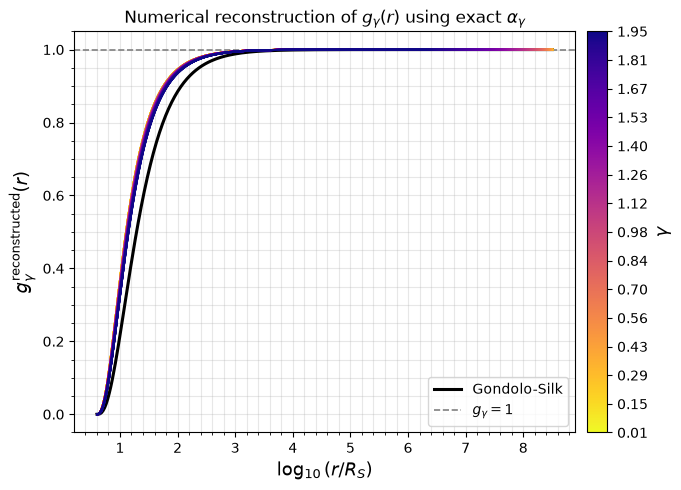

In [11]:
gamma_values = np.asarray(gamma_values, dtype=float)
r_cusp_grid = np.asarray(r_cusp_grid, dtype=float)
rho_cusp_grid = np.asarray(rho_cusp_grid, dtype=float)

if gamma_values.ndim != 1:
    raise ValueError("gamma_values must have shape (n_gamma,).")
if r_cusp_grid.ndim != 2 or rho_cusp_grid.ndim != 2:
    raise ValueError("r_cusp_grid and rho_cusp_grid must be two-dimensional.")
if r_cusp_grid.shape != rho_cusp_grid.shape:
    raise ValueError("r_cusp_grid and rho_cusp_grid must have the same shape.")
if r_cusp_grid.shape[0] != gamma_values.size:
    raise ValueError("The first grid dimension must match gamma_values.size.")

r0 = float(D)  # D is the r_0 used to calculate rho_cusp_grid.
# rho_D_values represents rho_0(gamma) with the normalization used to calculate rho_cusp_grid.
rho_D_values = np.asarray(
    rho0_iso * (1.0 - gamma_values / 3.0),
    dtype=float,
)

alpha_gamma_values_exact = np.asarray(
    alpha_gamma_exact(gamma_values),
    dtype=float,
)
R_sp_exact = (
    alpha_gamma_values_exact
    * r0
    * np.power(
        M / (rho_D_values * r0**3),
        1.0 / (3.0 - gamma_values),
    )
)
gamma_sp_values = (9.0 - 2.0 * gamma_values) / (4.0 - gamma_values)
rho_R_exact = rho_D_values * np.power(
    R_sp_exact / r0,
    -gamma_values,
)

with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
    rho_base_grid = rho_R_exact[:, None] * np.power(
        R_sp_exact[:, None] / r_cusp_grid,
        gamma_sp_values[:, None],
    )

valid_mask = (
    np.isfinite(r_cusp_grid)
    & (r_cusp_grid > 0.0)
    & (r_cusp_grid >= 4.0 * R_S)
    & np.isfinite(rho_cusp_grid)
    & (rho_cusp_grid >= 0.0)
    & np.isfinite(rho_base_grid)
    & (rho_base_grid > 0.0)
)
g_gamma_reconstructed = np.full_like(rho_cusp_grid, np.nan, dtype=float)
np.divide(
    rho_cusp_grid,
    rho_base_grid,
    out=g_gamma_reconstructed,
    where=valid_mask,
)

g_gamma_series = g_gamma_exact(
    r_cusp_grid,
    gamma_values[:, None],
    R_S,
)
comparison_mask = valid_mask & np.isfinite(g_gamma_series)
absolute_difference = np.abs(g_gamma_reconstructed - g_gamma_series)

if not np.any(valid_mask):
    raise ValueError("No valid points are available for reconstruction.")
if not np.any(comparison_mask):
    raise ValueError("No valid points are available for comparison.")

reconstructed_values = g_gamma_reconstructed[valid_mask]
print(
    f"g_gamma_reconstructed: min={np.min(reconstructed_values):.6e}, "
    f"max={np.max(reconstructed_values):.6e}; "
    f"max absolute error={np.max(absolute_difference[comparison_mask]):.6e}; "
    f"> 1 + 1e-6: {np.count_nonzero(reconstructed_values > 1.0 + 1e-6)}; "
    f"< -1e-6: {np.count_nonzero(reconstructed_values < -1e-6)}"
)

fig, ax = plt.subplots(figsize=(7, 5))
norm = Normalize(vmin=gamma_values.min(), vmax=gamma_values.max())
cmap = plt.get_cmap("plasma_r")

valid_radii = r_cusp_grid[valid_mask]
r_gs = np.geomspace(np.min(valid_radii), np.max(valid_radii), 300)
gs_line, = ax.plot(
    np.log10(r_gs / R_S),
    (1.0 - 4.0 * R_S / r_gs) ** 3,
    color="black",
    lw=2.2,
    label="Gondolo-Silk",
)
unity_line = ax.axhline(
    1.0,
    color="gray",
    ls="--",
    lw=1.2,
    label=r"$g_\gamma=1$",
)

for gamma_i, r_cusp_i, g_reconstructed_i, valid_i in zip(
    gamma_values,
    r_cusp_grid,
    g_gamma_reconstructed,
    valid_mask,
):
    ax.plot(
        np.log10(r_cusp_i[valid_i] / R_S),
        g_reconstructed_i[valid_i],
        color=cmap(norm(gamma_i)),
        lw=1.4,
        alpha=0.9,
    )

colorbar_source = ScalarMappable(norm=norm, cmap=cmap)
colorbar_source.set_array([])
colorbar = fig.colorbar(colorbar_source, ax=ax, pad=0.02)
colorbar.set_label(r"$\gamma$", fontsize=13)
gamma_ticks = np.linspace(gamma_values.min(), gamma_values.max(), 15)
colorbar.set_ticks(gamma_ticks)
colorbar.set_ticklabels([f"{gamma:.2f}" for gamma in gamma_ticks])

finite_reconstructed = g_gamma_reconstructed[np.isfinite(g_gamma_reconstructed)]
adaptive_upper = max(
    1.05,
    np.max(finite_reconstructed)
    + 0.05 * max(1.0, abs(np.max(finite_reconstructed))),
)
ax.set_ylim(top=adaptive_upper)
ax.set_xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
ax.set_ylabel(r"$g_\gamma^{\mathrm{reconstructed}}(r)$", fontsize=13)
ax.set_title(
    r"Numerical reconstruction of $g_\gamma(r)$ using exact $\alpha_\gamma$"
)
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()
ax.legend(handles=[gs_line, unity_line], loc="best", fontsize=10)

# r_cusp_grid keeps the radii built with the spline R_sp; extending or correcting each exact radial endpoint requires rebuilding the grid and recalculating the density.
fig.tight_layout()
plt.show()


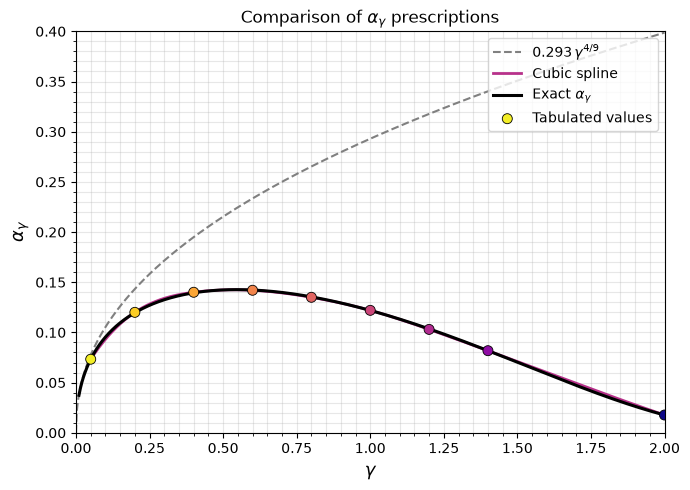

In [12]:
from scipy.interpolate import CubicSpline

alpha_data = np.array(
    [
        [0.05, 0.0733],
        [0.20, 0.1200],
        [0.40, 0.1400],
        [0.60, 0.1420],
        [0.80, 0.1350],
        [1.00, 0.1220],
        [1.20, 0.1030],
        [1.40, 0.0818],
        [2.00, 0.0177],
    ],
    dtype=float,
)

alpha_spline = CubicSpline(alpha_data[:, 0], alpha_data[:, 1])

gamma_asymptotic = np.linspace(0.0, 2.0, 800)
gamma_spline = np.linspace(0.05, 2.0, 800)
gamma_exact = np.linspace(0.01, 1.999, 800)

alpha_asymptotic = 0.293 * gamma_asymptotic ** (4.0 / 9.0)
alpha_spline_values = alpha_spline(gamma_spline)
alpha_exact_values = alpha_gamma_exact(gamma_exact)

fig, ax = plt.subplots(figsize=(7, 5))

norm = Normalize(vmin=0.0, vmax=2.0)
cmap = plt.get_cmap("plasma_r")

ax.plot(
    gamma_asymptotic,
    alpha_asymptotic,
    color="gray",
    lw=1.5,
    ls="--",
    label=r"$0.293\,\gamma^{4/9}$",
)
ax.plot(
    gamma_spline,
    alpha_spline_values,
    color=cmap(norm(1.15)),
    lw=2.0,
    label="Cubic spline",
)
ax.plot(
    gamma_exact,
    alpha_exact_values,
    color="black",
    lw=2.2,
    label=r"Exact $\alpha_\gamma$",
)
ax.scatter(
    alpha_data[:, 0],
    alpha_data[:, 1],
    c=alpha_data[:, 0],
    norm=norm,
    cmap=cmap,
    edgecolors="black",
    linewidths=0.6,
    s=52,
    zorder=3,
    label="Tabulated values",
)

ax.set_xlim(0.0, 2.0)
ax.set_ylim(0.0, 0.4)
ax.set_xlabel(r"$\gamma$", fontsize=13)
ax.set_ylabel(r"$\alpha_\gamma$", fontsize=13)
ax.set_title(r"Comparison of $\alpha_\gamma$ prescriptions")
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()
ax.legend(loc="upper right", fontsize=10)

fig.tight_layout()
plt.show()

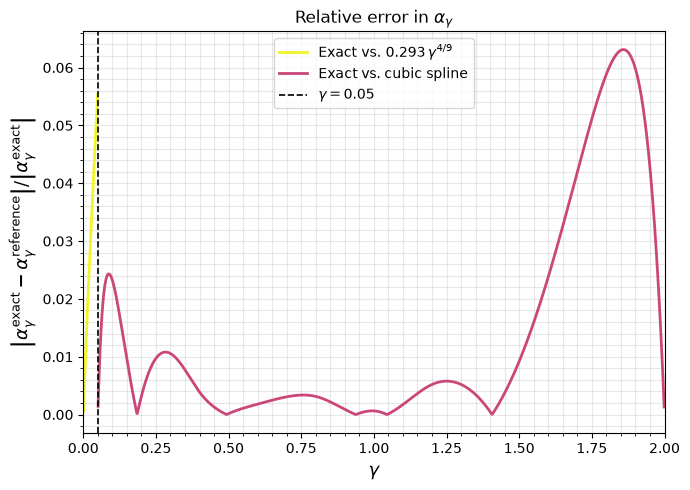

In [13]:
from scipy.interpolate import CubicSpline

alpha_data = np.array(
    [
        [0.05, 0.0733],
        [0.20, 0.1200],
        [0.40, 0.1400],
        [0.60, 0.1420],
        [0.80, 0.1350],
        [1.00, 0.1220],
        [1.20, 0.1030],
        [1.40, 0.0818],
        [2.00, 0.0177],
    ],
    dtype=float,
)

alpha_spline = CubicSpline(alpha_data[:, 0], alpha_data[:, 1])

gamma_error = np.linspace(1.0e-3, 1.999, 1200)
low_gamma_mask = gamma_error < 0.05
spline_gamma_mask = ~low_gamma_mask

alpha_exact_values = alpha_gamma_exact(gamma_error)
alpha_reference_values = np.empty_like(gamma_error)

alpha_reference_values[low_gamma_mask] = (
    0.293 * gamma_error[low_gamma_mask] ** (4.0 / 9.0)
)
alpha_reference_values[spline_gamma_mask] = alpha_spline(
    gamma_error[spline_gamma_mask]
)

relative_alpha_error = np.full_like(gamma_error, np.nan)
valid_mask = (
    np.isfinite(alpha_exact_values)
    & np.isfinite(alpha_reference_values)
    & (alpha_exact_values != 0.0)
)
np.divide(
    np.abs(alpha_exact_values - alpha_reference_values),
    np.abs(alpha_exact_values),
    out=relative_alpha_error,
    where=valid_mask,
)

fig, ax = plt.subplots(figsize=(7, 5))

norm = Normalize(vmin=0.0, vmax=2.0)
cmap = plt.get_cmap("plasma_r")

ax.plot(
    gamma_error[low_gamma_mask],
    relative_alpha_error[low_gamma_mask],
    color=cmap(norm(0.025)),
    lw=2.0,
    label=r"Exact vs. $0.293\,\gamma^{4/9}$",
)
ax.plot(
    gamma_error[spline_gamma_mask],
    relative_alpha_error[spline_gamma_mask],
    color=cmap(norm(1.0)),
    lw=2.0,
    label="Exact vs. cubic spline",
)
ax.axvline(
    0.05,
    color="black",
    lw=1.2,
    ls="--",
    label=r"$\gamma=0.05$",
)

ax.set_xlim(0.0, 2.0)
ax.set_xlabel(r"$\gamma$", fontsize=13)
ax.set_ylabel(
    r"$\left|\alpha_\gamma^{\mathrm{exact}}"
    r"-\alpha_\gamma^{\mathrm{reference}}\right|"
    r"/\left|\alpha_\gamma^{\mathrm{exact}}\right|$",
    fontsize=13,
)
ax.set_title(r"Relative error in $\alpha_\gamma$")
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()
ax.legend(loc="best", fontsize=10)

fig.tight_layout()
plt.show()

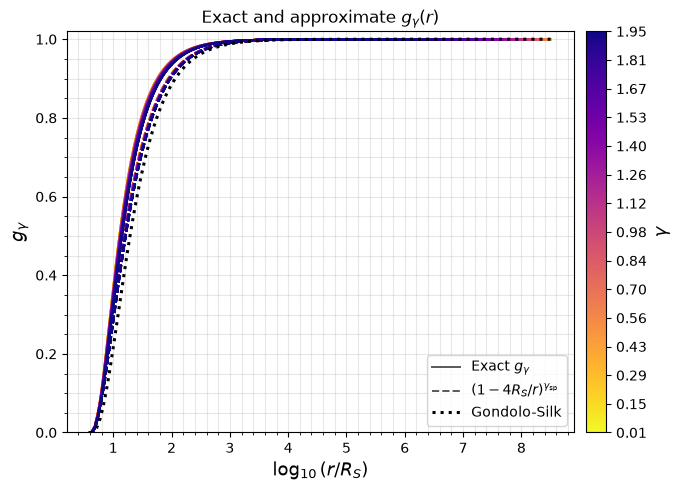

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

gamma_values = np.asarray(gamma_values, dtype=float)
r_cusp_grid = np.asarray(r_cusp_grid, dtype=float)

g_gamma_grid = g_gamma_exact(r_cusp_grid, gamma_values[:, None], R_S)
gamma_sp_values = (9.0 - 2.0 * gamma_values) / (4.0 - gamma_values)

fig, ax = plt.subplots(figsize=(7, 5))
norm = Normalize(vmin=gamma_values.min(), vmax=gamma_values.max())
cmap = plt.get_cmap("plasma_r")

for gamma_i, gamma_sp_i, r_i, g_exact_i in zip(
    gamma_values, gamma_sp_values, r_cusp_grid, g_gamma_grid
):
    valid_mask = (
        np.isfinite(r_i)
        & np.isfinite(g_exact_i)
        & (r_i >= 4.0 * R_S)
    )
    r_valid = r_i[valid_mask]
    x_values = np.log10(r_valid / R_S)
    color = cmap(norm(gamma_i))

    ax.plot(
        x_values, g_exact_i[valid_mask],
        color=color, lw=1.4, ls="-", alpha=0.9,
    )
    ax.plot(
        x_values, (1.0 - 4.0 * R_S / r_valid) ** gamma_sp_i,
        color=color, lw=1.4, ls="--", alpha=0.9,
    )

# La referencia Gondolo-Silk usa la union ordenada de los radios existentes.
r_gs = np.unique(
    r_cusp_grid[np.isfinite(r_cusp_grid) & (r_cusp_grid >= 4.0 * R_S)]
)
gs_line, = ax.plot(
    np.log10(r_gs / R_S),
    (1.0 - 4.0 * R_S / r_gs) ** 3,
    color="black", lw=2.2, ls=":", zorder=3,
    label="Gondolo-Silk",
)

colorbar_source = ScalarMappable(norm=norm, cmap=cmap)
colorbar_source.set_array([])
colorbar = fig.colorbar(colorbar_source, ax=ax, pad=0.02)
colorbar.set_label(r"$\gamma$", fontsize=13)
gamma_ticks = np.linspace(gamma_values.min(), gamma_values.max(), 15)
colorbar.set_ticks(gamma_ticks)
colorbar.set_ticklabels([f"{gamma:.2f}" for gamma in gamma_ticks])

legend_handles = [
    Line2D([], [], color="0.35", lw=1.4, ls="-", label=r"Exact $g_\gamma$"),
    Line2D(
        [], [], color="0.35", lw=1.4, ls="--",
        label=r"$(1-4R_S/r)^{\gamma_{\rm sp}}$",
    ),
    gs_line,
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
ax.set_xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
ax.set_ylabel(r"$g_\gamma$", fontsize=13)
ax.set_title(r"Exact and approximate $g_\gamma(r)$")
ax.set_ylim(0.0, 1.02)
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()

fig.tight_layout()
plt.show()